In [1]:
from PIL import Image

In [3]:
img = Image.open('tennis_vision.png')

In [38]:
import torch
import torchvision.models as models
from torchvision import transforms
class VisionModel():
    def __init__(self):
        self.model = models.resnet50(pretrained=True)
        self.model.fc = torch.nn.Linear(self.model.fc.in_features, 14*2)
        self.model.load_state_dict(torch.load('model_weights/best_model_noresize.pth', map_location=torch.device("cpu")))
    def predict(self, image):
        self.model.eval()
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor()])
        original_size = image.size
        image = transform(image)
        with torch.no_grad():
            image = image.unsqueeze(0) 
            output = self.model(image).cpu().detach().numpy().reshape(-1, 2)
            output[:, 0] *= original_size[0] / 224
            output[:, 1] *= original_size[1] / 224
            return output

In [39]:
vision_model = VisionModel()

/Users/gasparcartasso/Desktop/video_vision/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/gasparcartasso/Desktop/video_vision/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [35]:
vision_model.predict(img)

array([[ 70.62955 ,  62.467827],
       [151.43892 ,  62.28753 ],
       [ 37.885616, 175.07591 ],
       [185.15329 , 174.64548 ],
       [ 80.6665  ,  62.44084 ],
       [ 56.464367, 174.98088 ],
       [141.29034 ,  62.43    ],
       [166.39777 , 174.60555 ],
       [ 77.303406,  78.4864  ],
       [144.8993  ,  78.33998 ],
       [ 65.16945 , 134.9835  ],
       [157.48074 , 134.78839 ],
       [110.91155 ,  78.47504 ],
       [111.17374 , 134.94186 ]], dtype=float32)

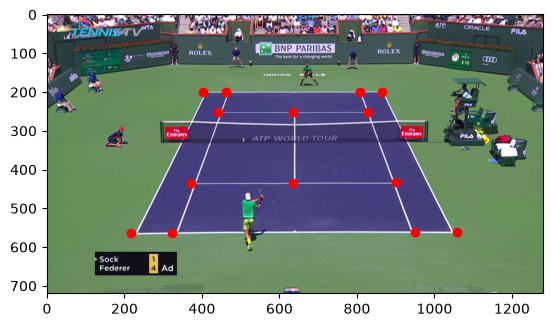

In [40]:
    import matplotlib.pyplot as plt
    plt.imshow(img)

    for point in vision_model.predict(img):
        x, y = point[:2]  # Adjust this if keypoints have more than 2 values
        plt.scatter(x, y, c='r', marker='o')  # Rescale to image size
    plt.show()